<a href="https://colab.research.google.com/github/thrisharadhakrishnan88-lang/world-bank-data-viz/blob/main/task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

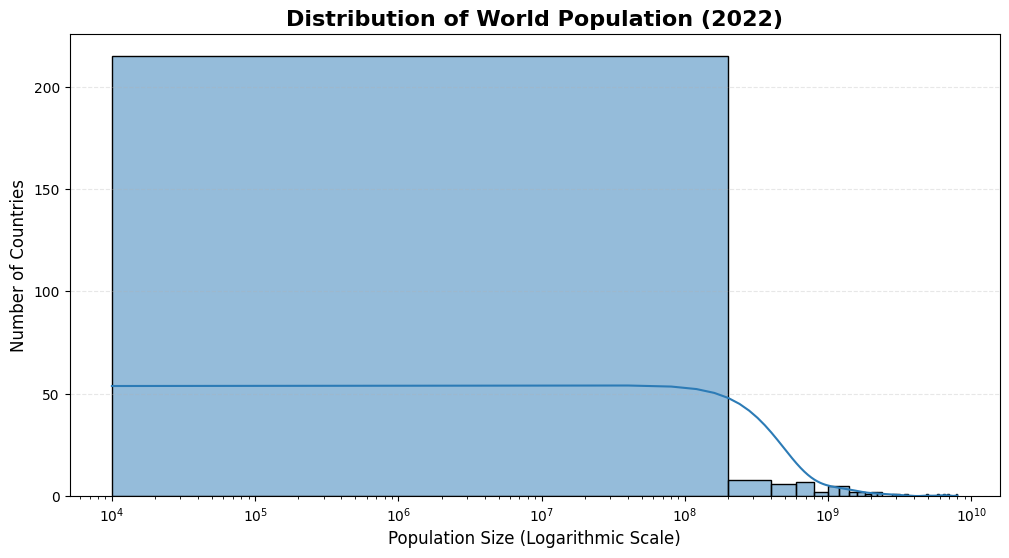

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The raw link you just generated
url = 'https://github.com/thrisharadhakrishnan88-lang/world-bank-data-viz/raw/refs/heads/main/API_SP.POP.TOTL_DS2_en_csv_v2_115541.csv'

# Load the data - skiprows=4 removes the World Bank metadata headers
df = pd.read_csv(url, skiprows=4)

# Filter for the year 2022 and remove any missing values
# Note: You can change '2022' to any year column available in your CSV
data_clean = df[['Country Name', '2022']].dropna()

# Create the Visualization
plt.figure(figsize=(12, 6))

# sns.histplot creates the bars; kde=True adds the smooth density line
sns.histplot(data_clean['2022'], bins=40, kde=True, color='#2c7bb6')

# Apply a Log Scale to make the data readable
plt.xscale('log')

# Adding labels and styling
plt.title('Distribution of World Population (2022)', fontsize=16, fontweight='bold')
plt.xlabel('Population Size (Logarithmic Scale)', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Show the plot
plt.show()

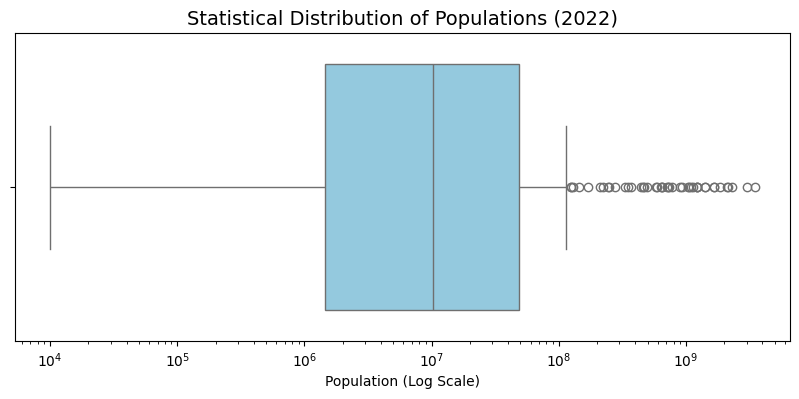

/tmp/ipykernel_5479/2719091518.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Growth_22_Years'] = df_clean['2022'] - df_clean['2000']
/tmp/ipykernel_5479/2719091518.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Growth_22_Years', y='Country Name', data=top_growers, palette='magma')


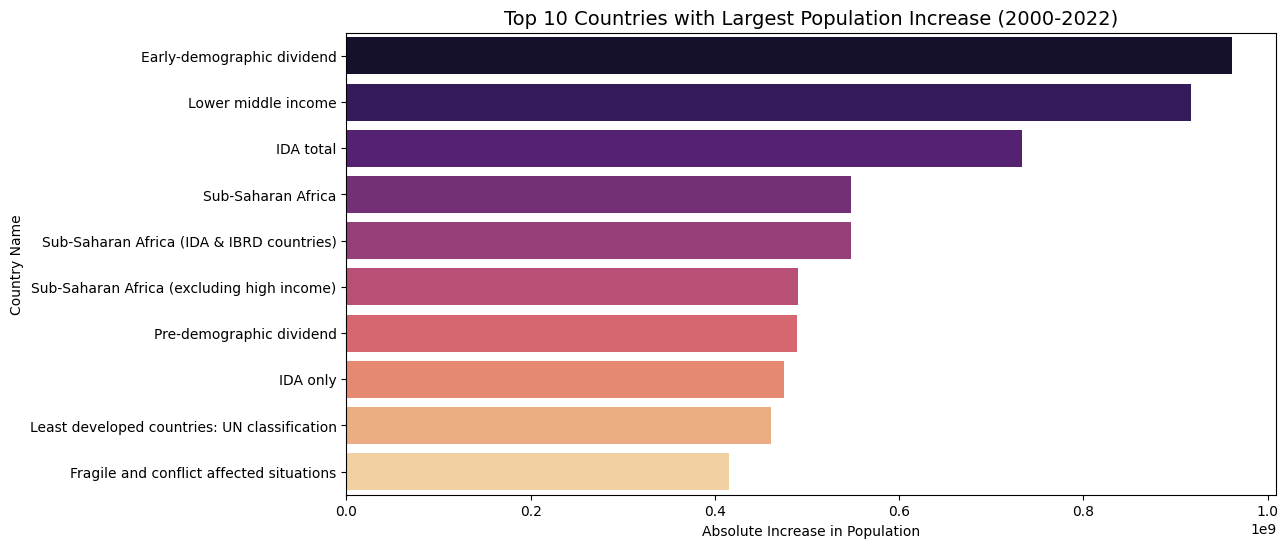

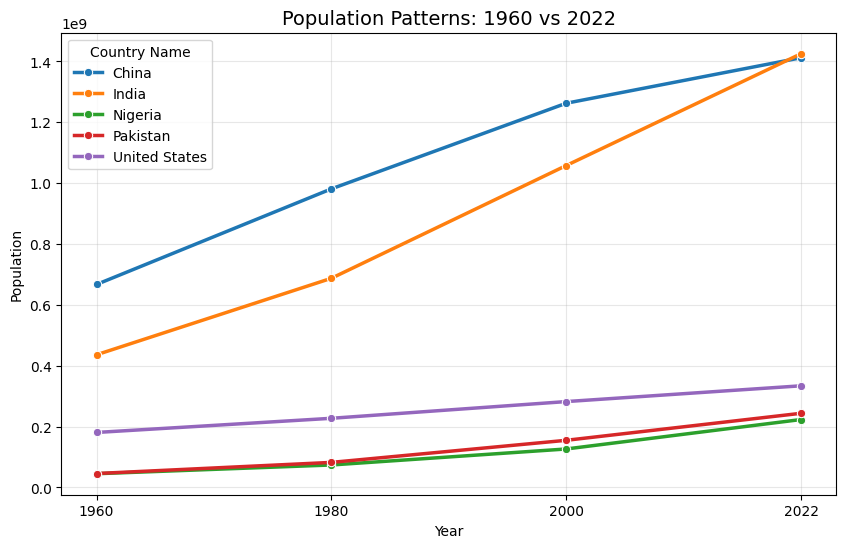

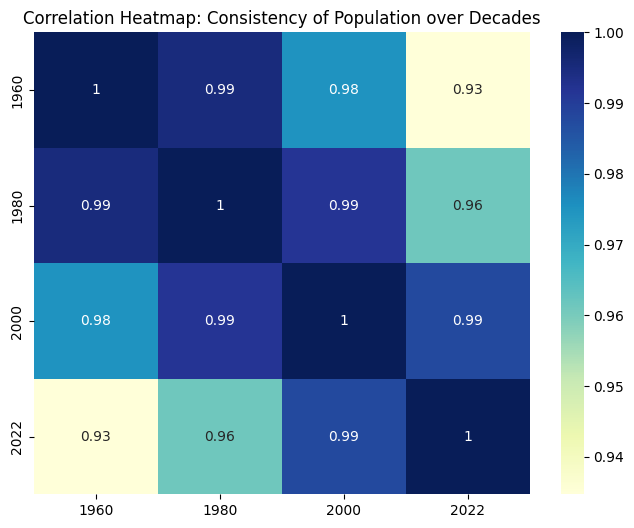

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. LOAD DATA
url = 'https://github.com/thrisharadhakrishnan88-lang/world-bank-data-viz/raw/refs/heads/main/API_SP.POP.TOTL_DS2_en_csv_v2_115541.csv'
df = pd.read_csv(url, skiprows=4)

# --- STEP 1: DATA CLEANING ---

# Identify non-country regions to exclude for a clean country-level analysis
# The World Bank includes 'World', 'Arab World', etc., which skew the data.
regions_to_exclude = [
    'World', 'High income', 'OECD members', 'Post-demographic dividend',
    'IDA & IBRD total', 'Low & middle income', 'Middle income',
    'IBRD only', 'East Asia & Pacific', 'Upper middle income'
]

# Create a clean dataframe with only individual countries
df_countries = df[~df['Country Name'].isin(regions_to_exclude)].copy()

# Handle Missing Values: Interpolate values for countries with missing years
# This fills gaps in time-series data based on surrounding years
df_countries.iloc[:, 4:] = df_countries.iloc[:, 4:].interpolate(axis=1)

# Drop any countries that still have null values for the year 2022
df_clean = df_countries.dropna(subset=['2022'])

# --- STEP 2: EXPLORATORY DATA ANALYSIS (EDA) ---

# A. Visualizing Distribution (Box Plot)
# Helps identify outliers (countries with massive populations)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['2022'], color='skyblue')
plt.xscale('log')
plt.title('Statistical Distribution of Populations (2022)', fontsize=14)
plt.xlabel('Population (Log Scale)')
plt.show()

# B. Identifying Patterns: Top 10 Growth Leaders
# We calculate the growth between 2000 and 2022
df_clean['Growth_22_Years'] = df_clean['2022'] - df_clean['2000']
top_growers = df_clean.sort_values(by='Growth_22_Years', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Growth_22_Years', y='Country Name', data=top_growers, palette='magma')
plt.title('Top 10 Countries with Largest Population Increase (2000-2022)', fontsize=14)
plt.xlabel('Absolute Increase in Population')
plt.show()

# C. Trend Analysis: Line Plot for specific countries
# This explores the "Time" trend variable
countries_to_track = ['India', 'China', 'United States', 'Nigeria', 'Pakistan']
trend_df = df_clean[df_clean['Country Name'].isin(countries_to_track)]

# Melt the dataframe to make it "Long-form" (Perfect for Seaborn Lineplots)
melted_df = trend_df.melt(id_vars=['Country Name'],
                          value_vars=['1960', '1980', '2000', '2022'],
                          var_name='Year', value_name='Population')

plt.figure(figsize=(10, 6))
sns.lineplot(data=melted_df, x='Year', y='Population', hue='Country Name', marker='o', linewidth=2.5)
plt.title('Population Patterns: 1960 vs 2022', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# D. Heatmap: Correlation between different years
# This identifies if population rankings remain consistent over decades
years_subset = df_clean[['1960', '1980', '2000', '2022']]
plt.figure(figsize=(8, 6))
sns.heatmap(years_subset.corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap: Consistency of Population over Decades')
plt.show()

In [12]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. LOAD DATA
# Using a hosted sample of the Twitter Sentiment140 dataset
url = 'https://raw.githubusercontent.com/kolaveridi/kaggle-Twitter-Sentiment-Analysis/master/train.csv'

try:
    # This dataset typically has columns: [ItemID, Sentiment, Content]
    # Sentiment: 0 = Negative, 1 = Positive
    df = pd.read_csv(url, encoding='latin-1')
    print("✅ Twitter Data Loaded!")

    # 2. PREPROCESSING FUNCTION
    def clean_tweet(text):
        text = re.sub(r'@[A-Za-z0-9]+', '', text) # Remove @mentions
        text = re.sub(r'https?://[A-Za-z0-9./]+', '', text) # Remove URLs
        text = re.sub(r'[^a-zA-Z]', ' ', text) # Remove punctuation/numbers
        text = text.lower().strip()
        return text

    df['clean_text'] = df['SentimentText'].apply(clean_tweet)

    # 3. VECTORIZATION (Turning text into numbers)
    # TF-IDF gives more weight to unique, meaningful words
    tfidf = TfidfVectorizer(max_features=5000)
    X = tfidf.fit_transform(df['clean_text'])
    y = df['Sentiment']

    # 4. SPLIT & TRAIN
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LogisticRegression()
    model.fit(X_train, y_train)

    # 5. EVALUATE
    y_pred = model.predict(X_test)
    print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # 6. TEST WITH YOUR OWN TWEET
    sample_tweet = ["I love learning data science with Gemini!"]
    sample_vec = tfidf.transform(sample_tweet)
    prediction = model.predict(sample_vec)
    sentiment = "Positive" if prediction[0] == 1 else "Negative"
    print(f"\nTest Tweet: '{sample_tweet[0]}' \nResult: {sentiment}")

except Exception as e:
    print(f"🛑 Error: {e}")

🛑 Error: HTTP Error 404: Not Found


In [ ]:
from google.colab import drive
drive.mount('/content/drive')